/home/developer/Documents/Tesi/code_old/.venv/lib/python3.12/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /home/developer/Documents/Tesi/code_old/.venv/lib/python3.12/site-packages/libpyg.so: undefined symbol: _ZN3c1010Dispatcher17runRecordFunctionERN2at14RecordFunctionESt17reference_wrapperIKNS_14FunctionSchemaEENS_11DispatchKeyE
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/developer/Documents/Tesi/code_old/.venv/lib/python3.12/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/developer/Documents/Tesi/code_old/.venv/lib/python3.12/site-packages/torch_scatter/_version_cpu.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/developer/Documents/Tesi/code_old/.venv/lib/python3.12/site-packages/to

tensor([[ 66,  65,  65,  ..., 138, 139, 139],
        [ 65, 141, 142,  ...,  74, 137, 138]], dtype=torch.int32)
Numero di nodi isolati:  0
Shape di data:  Data(x=[163, 200], edge_index=[2, 660], y=[163], name=[163])
  Statistic      Value
0      Mean   0.122145
1   Std Dev   4.152881
2       Min -26.557415
3       Max  28.152184
4    Median   0.056933


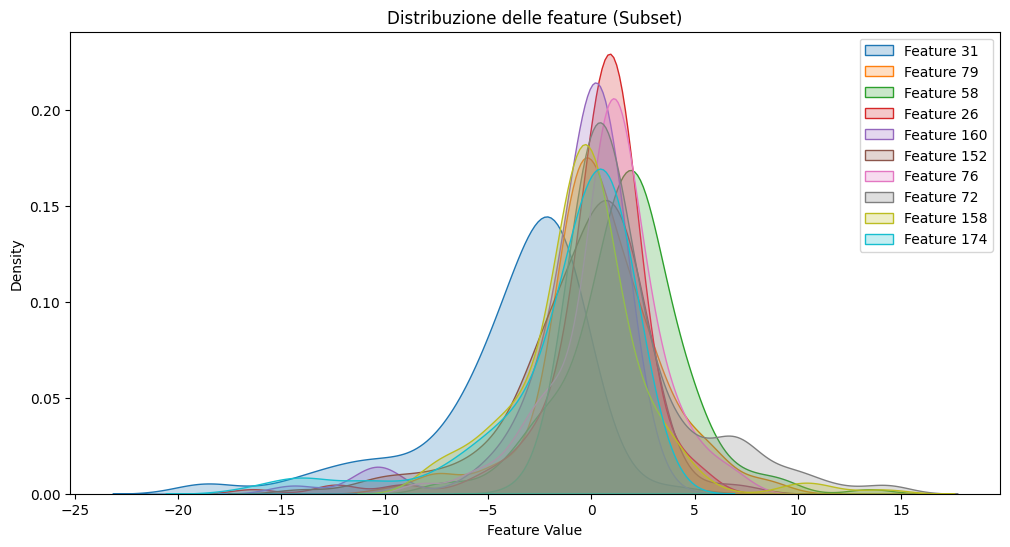

In [ ]:
DEBUG = False

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.data import Data
import seaborn as sns

nodes_df = pd.read_csv("../pre_processing_output/duplicated_nodes_main_components.csv")  # Dataset con nodi (proteine)
edges_df = pd.read_csv("../pre_processing_output/duplicated_edges_main_components.csv")  # Dataset con interazioni proteina-proteina
def make_dataset(nodes_df:pd.DataFrame, edges_df:pd.DataFrame):
    nodes_df['GO_embeddings'] = nodes_df['GO_embeddings'].apply(lambda x: torch.tensor(eval(x), dtype=torch.float))
    nodes_df['label'] = nodes_df['label'].apply(lambda x: torch.tensor(x, dtype=torch.float))

    # Aggiungo nodi al grafo
    G = nx.Graph()
    for _, row in nodes_df.iterrows():
        num_id = int(row['num_id'])
        G.add_node(num_id, name=row['STRING_id'], x=row['GO_embeddings'], y=torch.tensor(row['label'], dtype=torch.float))

    edges_df['num_id_1'] = edges_df['num_id_1'].astype(int)
    edges_df['num_id_2'] = edges_df['num_id_2'].astype(int)
    edges = torch.tensor(edges_df[['num_id_1', 'num_id_2']].values.T, dtype=torch.int)

    # Per visualizzazione debug
    G.add_edges_from(zip(edges_df['num_id_1'], edges_df['num_id_2']))

    print("Numero di nodi isolati: ", len(list(nx.isolates(G))))

    data = Data(
        x=torch.stack([G.nodes[n]['x'] for n in G.nodes]),  # Feature matrix
        edge_index=edges,  # Edge list
        y=torch.stack([G.nodes[n]['y'] for n in G.nodes]),
        name= [G.nodes[n]['name'] for n in G.nodes]
    )

    return data, G

nodes_emb_df = pd.read_csv("../pre_processing_output/duplicated_nodes_main_components.csv")  # Dataset con nodi (proteine)
nodes_sim_df = pd.read_csv("../pre_processing_output/duplicated_nodes_main_components_sim.csv")  # Dataset con nodi (proteine)
edges_df = pd.read_csv("../pre_processing_output/duplicated_edges_main_components.csv")  # Dataset con interazioni proteina-proteina
data_emb, _ = make_dataset(nodes_emb_df, edges_df)
data_sim, _ = make_dataset(nodes_sim_df, edges_df)

def feature_stats_and_visualization(data: Data):
    feature_values = data.x.cpu().numpy()

    # Calcolare statistiche comuni a tutte le feature
    mean_value = np.mean(feature_values)  # Media globale
    std_value = np.std(feature_values)    # Deviazione standard globale
    min_value = np.min(feature_values)    # Valore minimo globale
    max_value = np.max(feature_values)    # Valore massimo globale
    median_value = np.median(feature_values)  # Mediana globale

    global_stats = pd.DataFrame({
        "Statistic": ["Mean", "Std Dev", "Min", "Max", "Median"],
        "Value": [mean_value, std_value, min_value, max_value, median_value]
    })

    print(global_stats)

    num_features_to_plot = min(10, feature_values.shape[1])
    selected_features = np.random.choice(feature_values.shape[1], num_features_to_plot, replace=False)

    plt.figure(figsize=(12, 6))
    for feat_idx in selected_features:
        sns.kdeplot(feature_values[:, feat_idx], label=f'Feature {feat_idx}', fill=True)

    plt.xlabel("Feature Value")
    plt.ylabel("Density")
    plt.title("Distribuzione delle feature (Subset)")
    plt.legend()
    plt.show()

def graph_visualization(G: nx.Graph, data:Data):
    plt.figure(figsize=(8, 6))  # Imposta la dimensione della figura
    nx.draw(G, with_labels=True, node_size=50, font_size=8, edge_color="gray", node_color="blue")
    plt.title("Grafo costrutito da dataset")
    plt.show()

    G_temp = nx.Graph()
    G_temp.add_nodes_from(range(data.x.shape[0]))
    edges = data.edge_index.cpu().numpy()
    G_temp.add_edges_from(zip(edges[0], edges[1]))

    plt.figure(figsize=(8, 6))
    nx.draw(G_temp, with_labels=True, node_size=50, font_size=8, edge_color="gray", node_color="blue")
    plt.title("Grafo costruito da `data`")
    plt.show()

if DEBUG:
    feature_stats_and_visualization(data)
    graph_visualization(G, data)



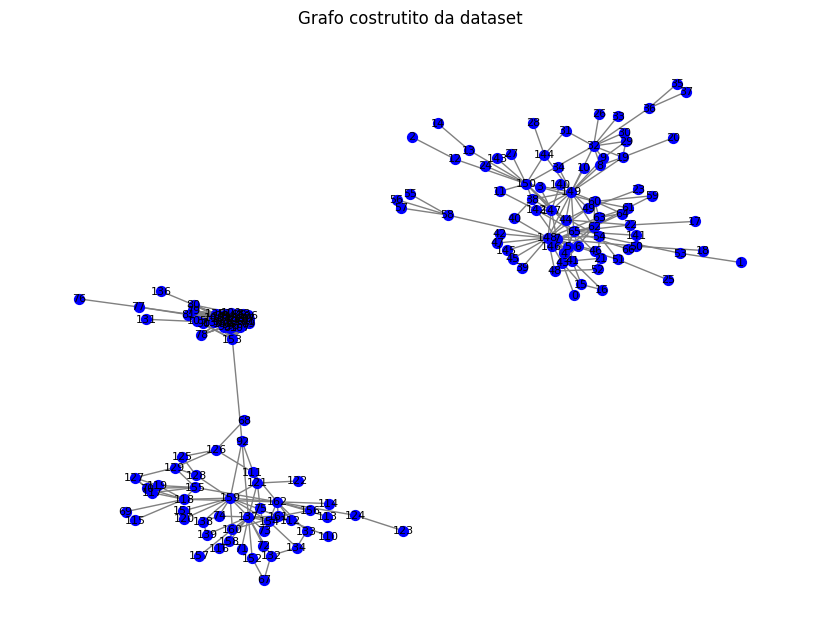

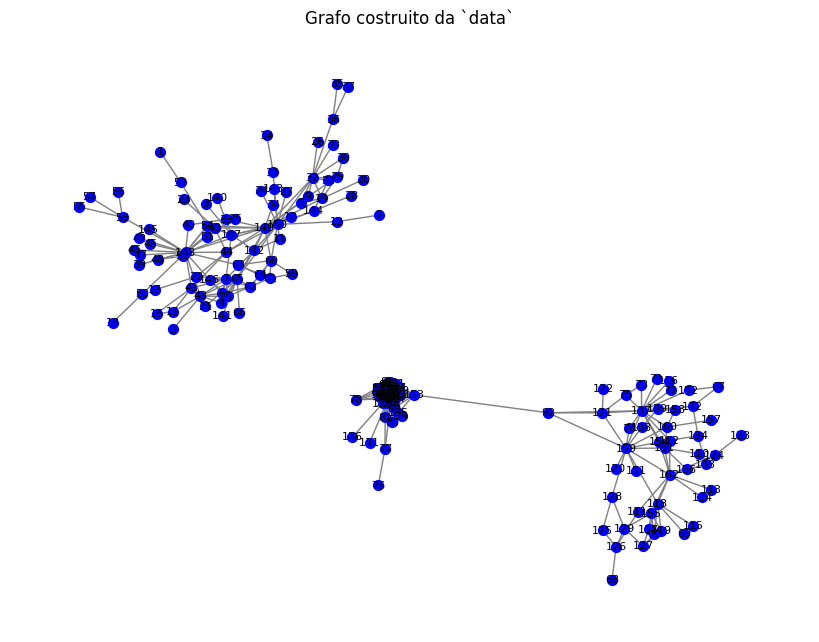

In [2]:
# CELLA DI DEBUG
import matplotlib.pyplot as plt
import networkx as nx

# PLOT GRAFO PRE DATA
plt.figure(figsize=(8, 6))  # Imposta la dimensione della figura
nx.draw(G, with_labels=True, node_size=50, font_size=8, edge_color="gray", node_color="blue")
plt.title("Grafo costrutito da dataset")
plt.show()
# PLOT DATO POST DATA

G_temp = nx.Graph()
G_temp.add_nodes_from(range(data.x.shape[0]))
edges = data.edge_index.cpu().numpy()
G_temp.add_edges_from(zip(edges[0], edges[1]))

plt.figure(figsize=(8, 6))
nx.draw(G_temp, with_labels=True, node_size=50, font_size=8, edge_color="gray", node_color="blue")
plt.title("Grafo costruito da `data`")
plt.show()

data.edge_index = data.edge_index.long()


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
import numpy as np
import torch.optim as optim
from torch_geometric.nn import SAGEConv
from torch_geometric.data import Data
from torch_geometric.utils import subgraph

class GCN_Sage(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1, dropout=0):
        super(GCN_Sage, self).__init__()
        
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.conv3 = SAGEConv(hidden_channels, out_channels)

        self.dropout = dropout
    
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.sigmoid(x)      
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.sigmoid(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv3(x, edge_index)
        return x.view(-1)  # Output logits
    
    def train_model(self, data, optimizer, criterion, epochs=200, patience=10, log=True):
        self.train()
        loss_values = []
        val_loss_values = []
        best_val_loss = float('inf')
        patience_counter = 0

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

        for epoch in range(epochs):
            optimizer.zero_grad()

            train_nodes = data.train_mask.nonzero(as_tuple=False).view(-1)
            edge_index_sub, _ = subgraph(train_nodes, data.edge_index, relabel_nodes=True)
            x_sub = data.x[train_nodes]
            y_sub = data.y[train_nodes]

            out = self.forward(x_sub, edge_index_sub)
            train_loss = criterion(out, y_sub.float())
            train_loss.backward()
            optimizer.step()

            self.eval()
            with torch.no_grad():
                val_out = self.forward(data.x, data.edge_index)
                val_loss = criterion(val_out[data.val_mask], data.y[data.val_mask].float())
            self.train()

            loss_values.append(train_loss.item())
            val_loss_values.append(val_loss.item())

            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered at epoch {epoch}")
                    break

            if epoch % 10 == 0 and log:
                print(f"Epoch {epoch}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        if log:
            plt.figure()
            plt.plot(range(len(loss_values)), loss_values, label='Training Loss')
            plt.plot(range(len(val_loss_values)), val_loss_values, label='Validation Loss', linestyle='dashed')
            plt.xlabel('Epochs')
            plt.ylabel('Loss')
            plt.title('Training & Validation Loss Curve')
            plt.legend()
            plt.show()
    
    def k_fold_cross_validation(self, data, k=5, epochs=50, learning_rate=0.001, patience=10, log=True):
        """
        Questa funzione imposta un k-fold cross validation stratificato assicurandosi di avere le proteine
        in comune sempre nel test set (sarebbe un data leakage altrimenti).
        Esegue i k training e stampa le metriche di valutazione, la media di queste ed il miglior modello allenato.
        """
        kf = StratifiedKFold(n_splits=k, shuffle=True)
        indices = np.arange(data.x.shape[0])
        common_proteins_mask = np.array(["_AD" in name or "_PD" in name for name in data.name])
        best_model = None
        best_f1 = 0
        acc_scores, precision_scores, recall_scores, f1_scores = [], [], [], []
        best_fold_metrics = {}
        best_cm = None

        # Fai un k-fold sul training dataset escludendo le proteine in comune
        usable_mask = (~common_proteins_mask) & data.kfold_usable_mask.cpu().numpy()
        usable_indices = np.where(usable_mask)[0]
        for fold, (train_idx, val_idx) in enumerate(kf.split(data.x[usable_mask], data.y[usable_mask].cpu().numpy())):   
            # Mappa indici locali a indici globali
            # N.B. Quando faccio qualcosa del tipo data.x[mask] sto selezionando un nuovo sottoinsieme del grafo dove ad ogni nodo
            #   verrà assegnato un nuovo indice "locale" perdendo il riferimento agli indici prima della selezione detti "globali".
            train_idx_global = usable_indices[train_idx]
            val_idx_global = usable_indices[val_idx]         
            if log: 
                print(f"\n🔹 Fold {fold+1}/{k}")
            train_mask = torch.zeros(data.x.shape[0], dtype=torch.bool)
            val_mask = torch.zeros(data.x.shape[0], dtype=torch.bool)
            
            # Aggiungi le proteine comuni al training set
            train_mask[common_proteins_mask] = True
            train_mask[train_idx_global] = True
            val_mask[val_idx_global] = True
            
            data.train_mask = train_mask
            data.val_mask = val_mask
            data.test_mask = ~train_mask

            model = GCN_Sage(in_channels=self.conv1.in_channels, 
                        hidden_channels=self.conv2.out_channels, 
                        out_channels=self.conv3.out_channels, 
                        dropout=self.dropout)
            optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=5e-4)
            criterion = torch.nn.BCEWithLogitsLoss()
            model.train_model(data, optimizer, criterion, epochs, patience, log=log)

            model.eval()
            with torch.no_grad():
                out = model(data.x, data.edge_index)
                out = torch.sigmoid(out)
                pred = (out[val_mask] > 0.5).int()
                y_true = data.y[val_mask].cpu().numpy()
                y_pred = pred.cpu().numpy()

                acc = accuracy_score(y_true, y_pred)
                precision = precision_score(y_true, y_pred)
                recall = recall_score(y_true, y_pred)
                f1 = f1_score(y_true, y_pred)
                cm = confusion_matrix(y_true, y_pred)

                acc_scores.append(acc)
                precision_scores.append(precision)
                recall_scores.append(recall)
                f1_scores.append(f1)

                if log:
                    print(f"Accuracy: {acc:.4f}")
                    print(f"Precision: {precision:.4f}")
                    print(f"Recall: {recall:.4f}")
                    print(f"F1-Score: {f1:.4f}")

                if f1 > best_f1:
                    best_f1 = f1
                    best_model = model
                    best_fold_metrics = {
                        "Accuracy": acc,
                        "Precision": precision,
                        "Recall": recall,
                        "F1-Score": f1,
                        "training_fold": train_idx,
                        "val_fold": val_idx
                    }
                    best_cm = cm

        if log:
            print("\n📊 **Statistiche medie della K-Fold Cross Validation**")
            print(f"Accuracy: {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
            print(f"Precision: {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
            print(f"Recall: {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
            print(f"F1-Score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")

            if best_cm is not None:
                plt.figure(figsize=(6,6))
                sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
                plt.xlabel("Predicted")
                plt.ylabel("Actual")
                plt.title("Confusion Matrix of Best Model")
                plt.show()
        
        return best_model, best_fold_metrics



🔹 Fold 1/5
Epoch 0, Train Loss: 0.6815, Val Loss: 0.6484, LR: 0.001000
Epoch 10, Train Loss: 0.5915, Val Loss: 0.5193, LR: 0.001000
Epoch 20, Train Loss: 0.4905, Val Loss: 0.3990, LR: 0.001000
Epoch 30, Train Loss: 0.3837, Val Loss: 0.2826, LR: 0.001000
Epoch 40, Train Loss: 0.2873, Val Loss: 0.1952, LR: 0.001000


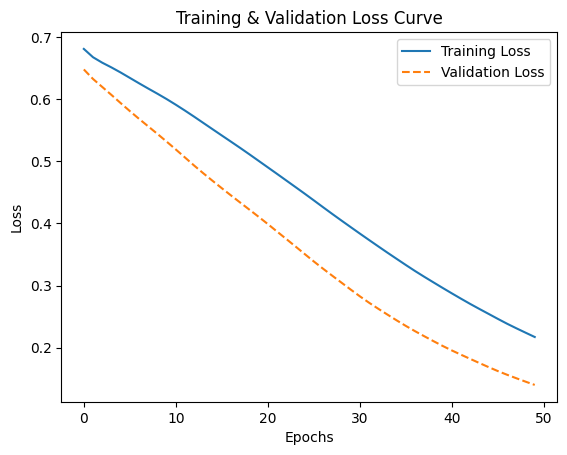

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

🔹 Fold 2/5
Epoch 0, Train Loss: 0.6877, Val Loss: 0.6476, LR: 0.001000
Epoch 10, Train Loss: 0.5825, Val Loss: 0.5960, LR: 0.001000
Epoch 20, Train Loss: 0.4711, Val Loss: 0.5318, LR: 0.001000
Epoch 30, Train Loss: 0.3575, Val Loss: 0.4692, LR: 0.001000
Epoch 40, Train Loss: 0.2545, Val Loss: 0.4150, LR: 0.001000


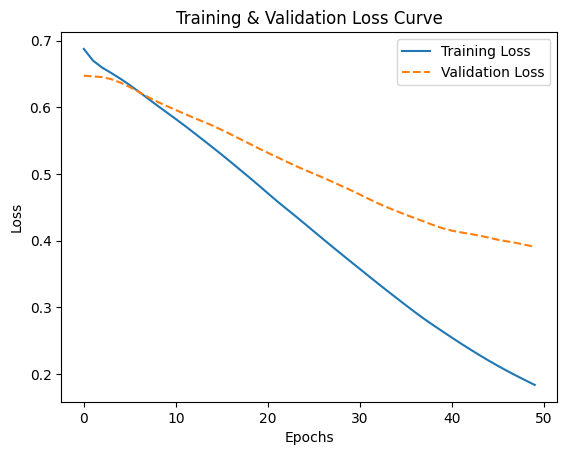

Accuracy: 0.7600
Precision: 0.7059
Recall: 0.9231
F1-Score: 0.8000

🔹 Fold 3/5
Epoch 0, Train Loss: 0.6959, Val Loss: 0.6864, LR: 0.001000
Epoch 10, Train Loss: 0.5859, Val Loss: 0.5988, LR: 0.001000
Epoch 20, Train Loss: 0.4803, Val Loss: 0.5056, LR: 0.001000
Epoch 30, Train Loss: 0.3732, Val Loss: 0.4210, LR: 0.001000
Epoch 40, Train Loss: 0.2716, Val Loss: 0.3396, LR: 0.001000


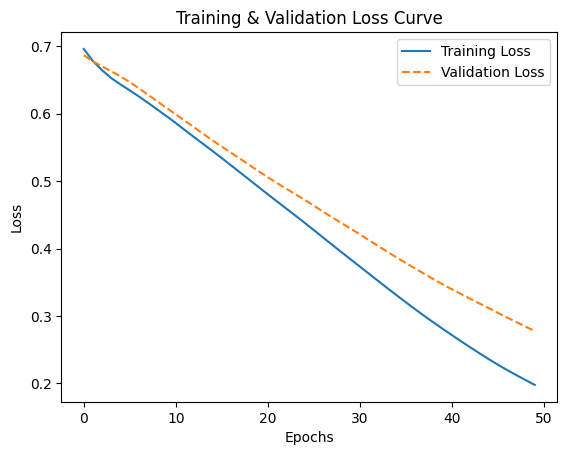

Accuracy: 0.9200
Precision: 1.0000
Recall: 0.8462
F1-Score: 0.9167

🔹 Fold 4/5
Epoch 0, Train Loss: 0.7636, Val Loss: 0.7304, LR: 0.001000
Epoch 10, Train Loss: 0.6319, Val Loss: 0.6281, LR: 0.001000
Epoch 20, Train Loss: 0.5596, Val Loss: 0.5610, LR: 0.001000
Epoch 30, Train Loss: 0.4778, Val Loss: 0.4979, LR: 0.001000
Epoch 40, Train Loss: 0.3884, Val Loss: 0.4353, LR: 0.001000


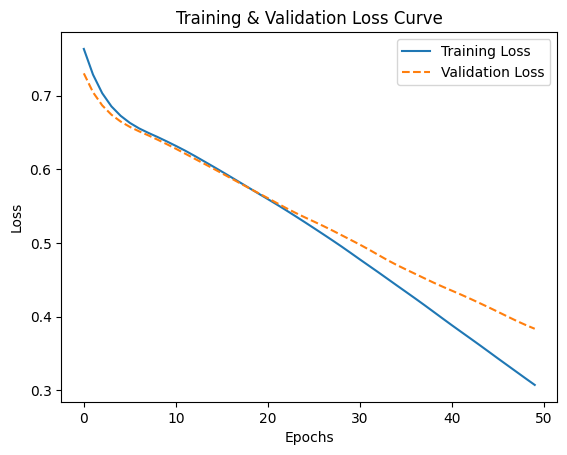

Accuracy: 0.9200
Precision: 1.0000
Recall: 0.8571
F1-Score: 0.9231

🔹 Fold 5/5
Epoch 0, Train Loss: 0.6964, Val Loss: 0.6851, LR: 0.001000
Epoch 10, Train Loss: 0.6049, Val Loss: 0.5873, LR: 0.001000
Epoch 20, Train Loss: 0.5040, Val Loss: 0.4700, LR: 0.001000
Epoch 30, Train Loss: 0.3966, Val Loss: 0.3703, LR: 0.001000
Epoch 40, Train Loss: 0.2906, Val Loss: 0.2965, LR: 0.001000


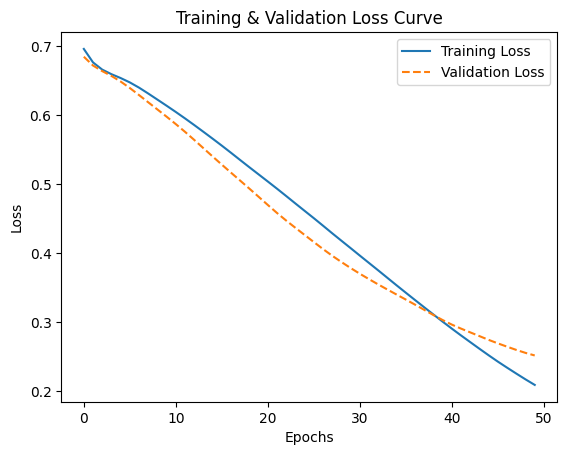

Accuracy: 0.8800
Precision: 1.0000
Recall: 0.7857
F1-Score: 0.8800

📊 **Statistiche medie della K-Fold Cross Validation**
Accuracy: 0.8960 ± 0.0784
Precision: 0.9412 ± 0.1176
Recall: 0.8824 ± 0.0732
F1-Score: 0.9039 ± 0.0650


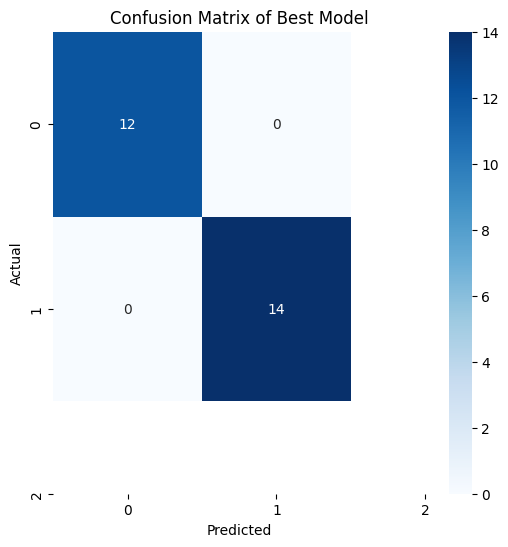


🧪 **Valutazione sul test set finale (10%)**
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000


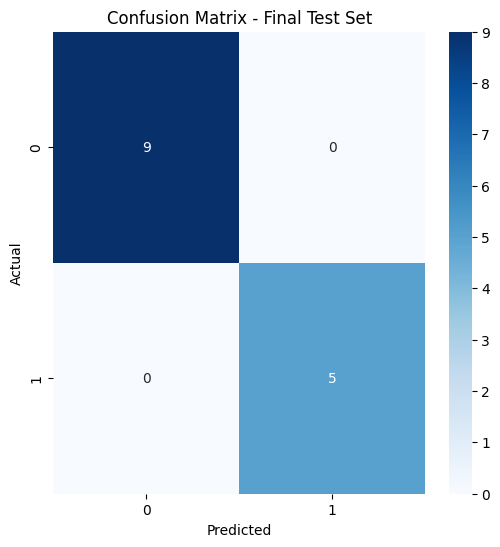

In [5]:
from torch.optim import Adam
import random


NUM_ITERATIONS = 100
LR = 0.001

# Escludendo le proteine in comune estrai un 10% per testing finale
common_proteins_mask = np.array(["_AD" in name or "_PD" in name for name in data.name])
non_common_indices = np.where(~common_proteins_mask)[0]

num_test = int(0.1 * len(non_common_indices))
final_test_indices = np.random.choice(non_common_indices, size=num_test, replace=False)
final_test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
final_test_mask[final_test_indices] = True

data.final_test_mask = final_test_mask
data.kfold_usable_mask = ~(final_test_mask)

# Inizializzo il modello
model = GCN_Sage(in_channels=data.x.shape[1], hidden_channels=64, out_channels=1, dropout=0)
optimizer = Adam(model.parameters(), lr=LR, weight_decay=5e-4)
best_model, best_metrics = model.k_fold_cross_validation(data, k=5, epochs=50, learning_rate=LR, patience=10, log=True)

# Testing su dataset precedentemente estratto
best_model.eval()
with torch.no_grad():
    out = best_model(data.x, data.edge_index)
    out = torch.sigmoid(out)

    pred = (out[data.final_test_mask] > 0.5).int()
    y_true = data.y[data.final_test_mask].cpu().numpy()
    y_pred = pred.cpu().numpy()

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print("\n🧪 **Valutazione sul test set finale (10%)**")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - Final Test Set")
    plt.show()


In [7]:
# Questo codice serve per controllare la frequenza dei sample nella fold con più alte metriche

DEBUG = True

if DEBUG:
    from torch.optim import Adam
    from tqdm import tqdm
    import numpy as np

    NUM_ITERATIONS = 100
    LR = 0.001

    best_metrics_list = []

    with tqdm(total=NUM_ITERATIONS, desc="Training Progress", unit="iteration") as pbar:
        for _ in range(NUM_ITERATIONS):
            model = GCN_Sage(in_channels=data.x.shape[1], hidden_channels=64, out_channels=1, dropout=0)
            optimizer = Adam(model.parameters(), lr=LR, weight_decay=5e-4)

            _, best_metrics = model.k_fold_cross_validation(data, k=5, epochs=50, learning_rate=LR, patience=10, log=False)
            best_metrics_list.append(best_metrics)
            pbar.update(1)

    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    avg_metrics = {}
    std_metrics = {}
    for m in metrics:
        avg_metrics[m] = np.mean([metric[m] for metric in best_metrics_list], dtype='float64')
        std_metrics[m] = np.std([metric[m] for metric in best_metrics_list], dtype='float64')

    print('Average metrics over 100 iterations')
    for metric in metrics:
        print(f'{metric} = {avg_metrics[metric]:.5f} {std_metrics[metric]:.5f}')



Training Progress:   1%|          | 1/100 [00:02<04:21,  2.65s/iteration]

Early stopping triggered at epoch 16


Training Progress:   9%|▉         | 9/100 [00:51<04:49,  3.19s/iteration]

Early stopping triggered at epoch 33


Training Progress:  25%|██▌       | 25/100 [01:23<02:17,  1.84s/iteration]

...

Early stopping triggered at epoch 19


Training Progress:  99%|█████████▉| 99/100 [03:37<00:01,  1.17s/iteration]

Early stopping triggered at epoch 49


Training Progress: 100%|██████████| 100/100 [03:38<00:00,  2.18s/iteration]

Average metrics over 100 iterations
Accuracy = 0.92380 0.03655
Precision = 0.92847 0.06040
Recall = 0.93769 0.05005
F1-Score = 0.93080 0.03253
